# Axisymmetric LNS Free-Surface Solver — Visualisation

This notebook runs the axisymmetric solver from `surface_dynamics_axi.py`,
visualises the radial wave evolution, and produces a GIF.

The setup: a Gaussian bump centered at the axis ($r=0$) on a quiescent fluid
surface. By axisymmetry, the disturbance is rotationally symmetric, so we only
solve along $r \in [0, L]$.


In [1]:
%cd /Users/helloworld/Home/Desktop/amugeona/LNS_floating/11_Surface_Dynamics_3dAxiSymm


/Users/helloworld/Home/Desktop/amugeona/LNS_floating/11_Surface_Dynamics_3dAxiSymm


In [2]:
from surface_dynamics_axi import (
    SurfaceDynamicsSolverAxi, SimConfig,
    PhysicalParams, NumericalParams, InitialCondition,
)

# Reasonable production-ish run
config = SimConfig(
    phys=PhysicalParams(L_cm=200.0, D_cm=20.0, nu=0.0005),
    num=NumericalParams(nr=320, nz=80, nt=2000, total_time_s=1.5),
    ic=InitialCondition(amplitude_cm=0.05, width_cm=5.0),
)
solver = SurfaceDynamicsSolverAxi(config)
result = solver.run()


SurfaceDynamicsSolverAxi initialised
  Domain: r ∈ [0, 200.0] cm,  z ∈ [-20.0, 0] cm
  Grid: nr=320, nz=80
  Fr=1.0204, We=35.7347, Re=250000
  Monolithic size N = 77120, nnz = 382246
  Matrix build: 0.39s,  LU factor: 0.40s
  dt = 0.750 ms, 2000 steps

Running 2000 steps...
  Step     1 | t=0.0008s | max|eta|=0.019997 | max|phi|=0.000298
  Step     2 | t=0.0015s | max|eta|=0.019992 | max|phi|=0.000596
  Step     3 | t=0.0022s | max|eta|=0.019984 | max|phi|=0.000894
  Step   100 | t=0.0750s | max|eta|=0.008254 | max|phi|=0.023641
  Step   200 | t=0.1500s | max|eta|=0.010082 | max|phi|=0.021261
  Step   300 | t=0.2250s | max|eta|=0.012062 | max|phi|=0.010097
  Step   400 | t=0.3000s | max|eta|=0.005729 | max|phi|=0.008031
  Step   500 | t=0.3750s | max|eta|=0.004849 | max|phi|=0.006127
  Step   600 | t=0.4500s | max|eta|=0.003788 | max|phi|=0.004843
  Step   700 | t=0.5250s | max|eta|=0.003168 | max|phi|=0.004151
  Step   800 | t=0.6000s | max|eta|=0.003123 | max|phi|=0.003817
  Step   

## Plot 1: axis trace and radial snapshots

The trace at $r=0$ shows the temporal evolution of the surface peak; snapshots
at several times show the Gaussian spreading outward as a circular wave.

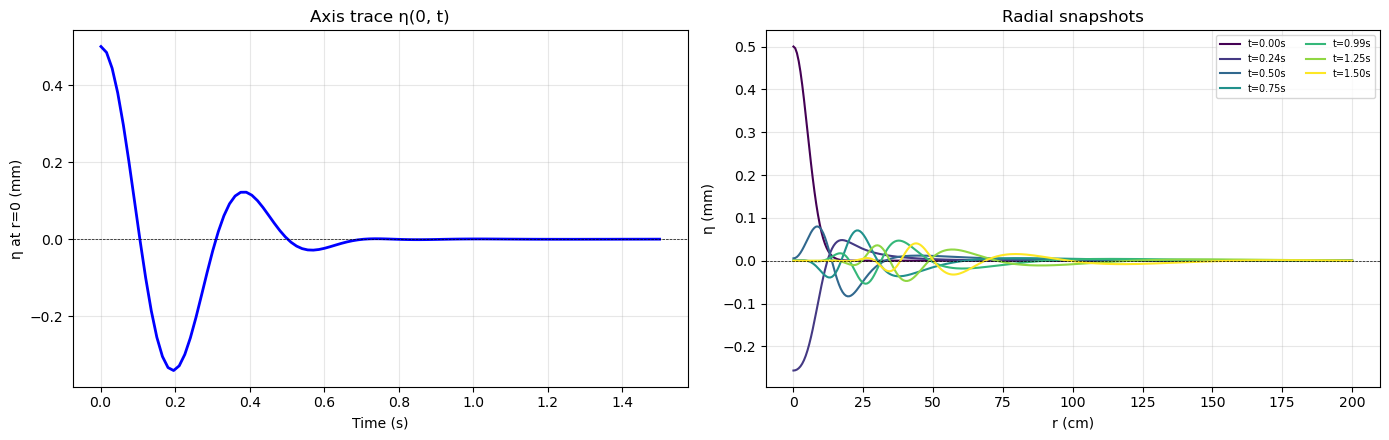

In [3]:
import matplotlib.pyplot as plt
import numpy as np

uL = config.num.unit_length
ut = config.num.unit_time
r_cm = result["r"] * uL
t = result["time"]
eta_arr = np.array(result["eta_history"]) * uL * 10  # mm

# 2-panel layout
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Axis trace
ax = axes[0]
ax.plot(t, eta_arr[:, 0], "b-", lw=2)
ax.axhline(0, color="k", ls="--", lw=0.5)
ax.set(xlabel="Time (s)", ylabel="η at r=0 (mm)", title="Axis trace η(0, t)")
ax.grid(alpha=0.3)

# Radial snapshots
ax = axes[1]
n_snap = 7
idx = np.linspace(0, len(t) - 1, n_snap, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, n_snap))
for i, c in zip(idx, colors):
    ax.plot(r_cm, eta_arr[i], color=c, lw=1.5, label=f"t={t[i]:.2f}s")
ax.axhline(0, color="k", ls="--", lw=0.5)
ax.set(xlabel="r (cm)", ylabel="η (mm)", title="Radial snapshots")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## Plot 2: space-time diagram

A 2D plot of η(r, t) shows the wavefront propagating outward from the axis.

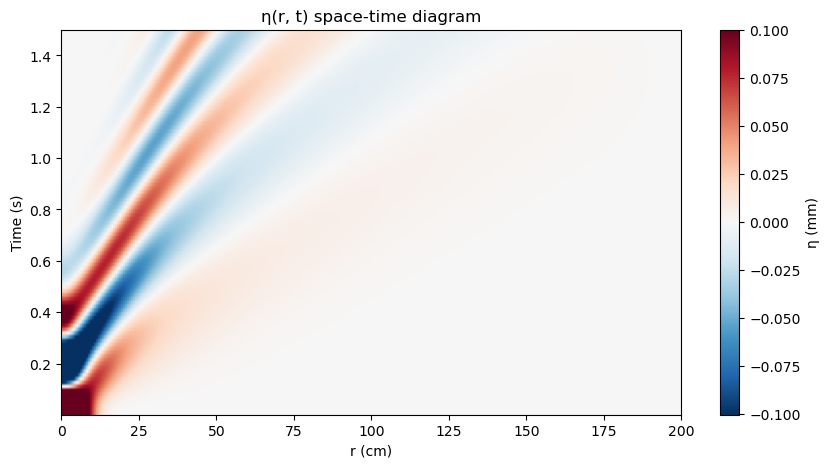

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
vmax = max(1e-6, np.percentile(np.abs(eta_arr), 99))
im = ax.imshow(eta_arr, aspect="auto", origin="lower",
               extent=[r_cm[0], r_cm[-1], t[0], t[-1]],
               cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set(xlabel="r (cm)", ylabel="Time (s)", title="η(r, t) space-time diagram")
plt.colorbar(im, ax=ax, label="η (mm)")
plt.show()


## Plot 3: top-down view (2D rendering of the axisymmetric surface)

Since the solution is rotationally symmetric, η(x, y, t) = η(√(x²+y²), t). We render the full 2D pattern by reflecting the radial profile across the axis.

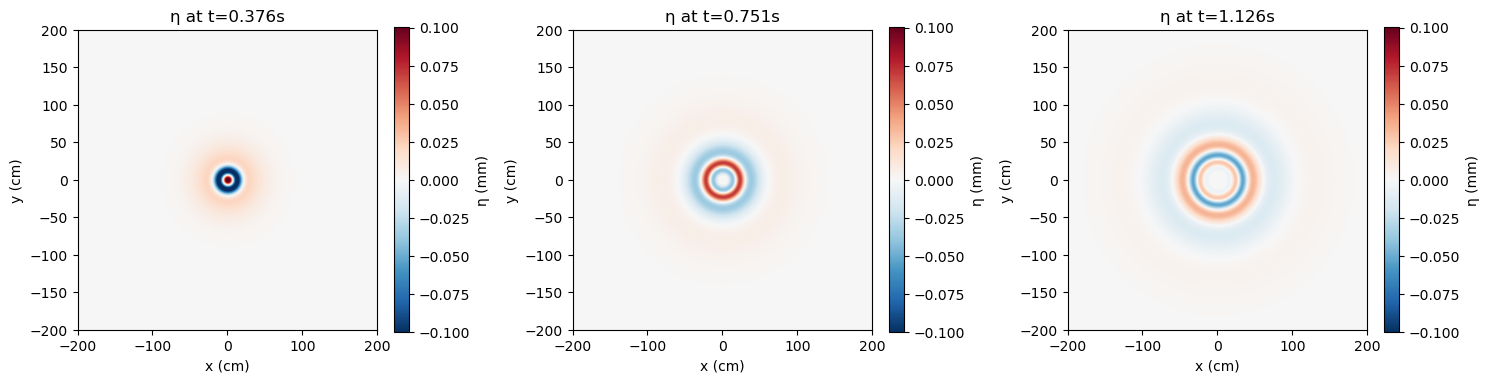

In [5]:
def render_topdown(eta_radial, r_cm, n_pixels=300):
    '''Reflect a radial profile into a 2D top-down image.'''
    # Build 2D grid of (x, y) points and look up eta at sqrt(x²+y²).
    R = r_cm[-1]
    x = np.linspace(-R, R, n_pixels)
    y = np.linspace(-R, R, n_pixels)
    X, Y = np.meshgrid(x, y)
    rho = np.sqrt(X**2 + Y**2)
    # Linear interpolation onto rho grid (mask out rho > R)
    eta_2d = np.interp(rho, r_cm, eta_radial, right=0.0)
    return X, Y, eta_2d

# Render at three time instants: t/4, t/2, 3t/4 of total run
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
times_to_show = [len(t) // 4, len(t) // 2, 3 * len(t) // 4]
vmax = max(1e-6, np.percentile(np.abs(eta_arr), 99))
for ax, idx in zip(axes, times_to_show):
    X, Y, eta_2d = render_topdown(eta_arr[idx], r_cm)
    im = ax.imshow(eta_2d, origin="lower", extent=[X.min(), X.max(), Y.min(), Y.max()],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set(xlabel="x (cm)", ylabel="y (cm)", title=f"η at t={t[idx]:.3f}s")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, label="η (mm)", fraction=0.046)
fig.tight_layout()
plt.show()


## GIF: axisymmetric surface evolution

Two-panel animation: radial profile on the left, top-down 2D view on the right.

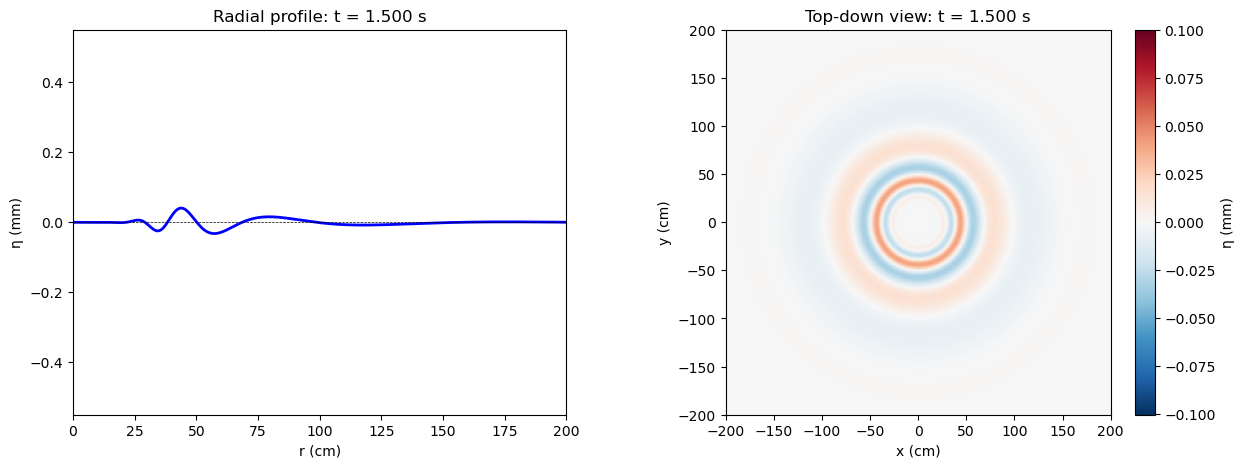

Saved Outputs/axi_surface.gif  (fps=13, duration ≈ 7.8 s)


In [6]:
from matplotlib.animation import FuncAnimation, PillowWriter
import os
os.makedirs("Outputs", exist_ok=True)

# Pick GIF playback duration (seconds)
gif_duration_seconds = 8.0   # change this to slow down or speed up
n_frames = len(t)
fps = max(1, int(round(n_frames / gif_duration_seconds)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: radial profile
ax1 = axes[0]
y_max = float(np.max(np.abs(eta_arr)))
line, = ax1.plot(r_cm, eta_arr[0], "b-", lw=2)
ax1.axhline(0, color="k", ls="--", lw=0.5)
ax1.set(xlim=[r_cm[0], r_cm[-1]], ylim=[-1.1 * y_max, 1.1 * y_max],
        xlabel="r (cm)", ylabel="η (mm)")
title1 = ax1.set_title("Radial profile: t = 0.000 s")

# Right panel: top-down 2D
ax2 = axes[1]
X, Y, eta_2d = render_topdown(eta_arr[0], r_cm)
vmax = max(1e-6, np.percentile(np.abs(eta_arr), 99))
im = ax2.imshow(eta_2d, origin="lower", extent=[X.min(), X.max(), Y.min(), Y.max()],
                cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax2.set(xlabel="x (cm)", ylabel="y (cm)")
ax2.set_aspect("equal")
title2 = ax2.set_title("Top-down view: t = 0.000 s")
plt.colorbar(im, ax=ax2, label="η (mm)", fraction=0.046)

def update(i):
    line.set_ydata(eta_arr[i])
    _, _, eta_2d = render_topdown(eta_arr[i], r_cm)
    im.set_data(eta_2d)
    title1.set_text(f"Radial profile: t = {t[i]:.3f} s")
    title2.set_text(f"Top-down view: t = {t[i]:.3f} s")
    return line, im

anim = FuncAnimation(fig, update, frames=n_frames, interval=40, blit=False)
anim.save("./Outputs/axi_surface.gif", writer=PillowWriter(fps=fps), dpi=120)
plt.show()
print(f"Saved Outputs/axi_surface.gif  (fps={fps}, duration ≈ {n_frames/fps:.1f} s)")


## Diagnostics: mass conservation, energy

Mass drift over run: 252.82%


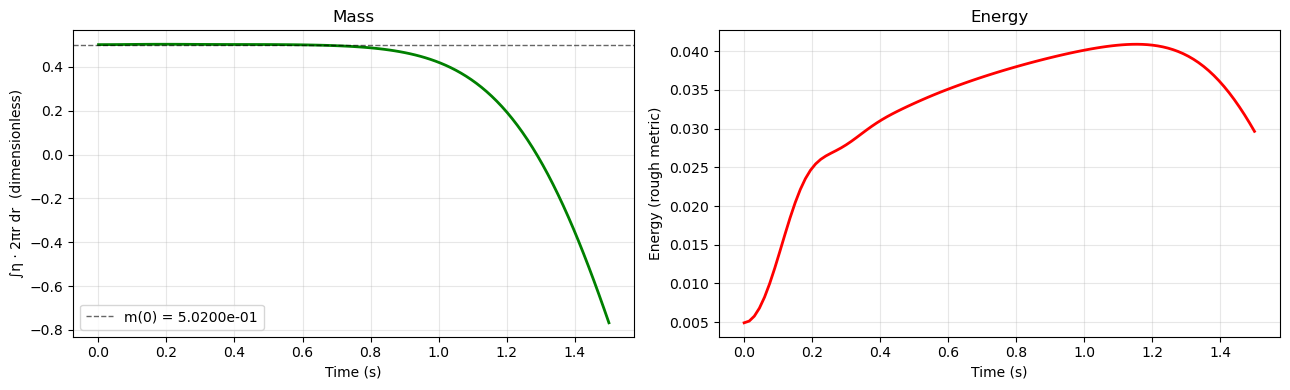

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mass
ax = axes[0]
m = result["mass"]
ax.plot(t, m, "g-", lw=2)
ax.axhline(m[0], color="k", ls="--", lw=1, alpha=0.6, label=f"m(0) = {m[0]:.4e}")
ax.set(xlabel="Time (s)", ylabel="∫η · 2πr dr  (dimensionless)", title="Mass")
ax.legend()
ax.grid(alpha=0.3)
print(f"Mass drift over run: {abs(m[-1]-m[0])/abs(m[0]):.2%}")

# Energy (note: this is a rough metric, not strictly conserved due to viscous loss)
ax = axes[1]
E = result["energy"]
ax.plot(t, E, "r-", lw=2)
ax.set(xlabel="Time (s)", ylabel="Energy (rough metric)", title="Energy")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## 3D rendered GIF

Render η(x, y, t) as a 3D surface using `plot_surface`. Since the solution is
axisymmetric, η at any (x, y) is just η(√(x²+y²), t).  We use light-source shading
and a perceptual colormap for an elegant look.


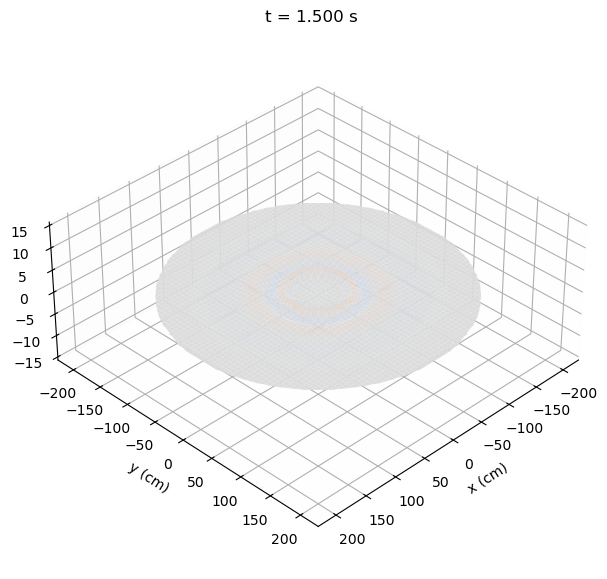

Saved Outputs/axi_3d.gif  (13 fps, ≈ 7.8 s playback, exaggeration ×30)


In [8]:
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LightSource
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("Outputs", exist_ok=True)

# --- Parameters ---
n_pixels = 180        # 2D image resolution (n_pixels x n_pixels)
zoom = 1.0            # fraction of full domain to render (1.0 = full L)
gif_duration_seconds = 8.0
elev, azim = 35, 45   # 3D view angles
exaggeration = 30     # vertical scaling so ripples are visible

# --- Build (x, y) grid restricted to a circle of radius zoom * L ---
R_max = float(r_cm[-1]) * zoom
x = np.linspace(-R_max, R_max, n_pixels)
y = np.linspace(-R_max, R_max, n_pixels)
X, Y = np.meshgrid(x, y)
rho = np.sqrt(X**2 + Y**2)

def eta_2d_for_frame(idx):
    """Reflect the radial profile into the 2D pattern, masking outside the disk."""
    eta_2d = np.interp(rho, r_cm, eta_arr[idx], right=0.0)
    eta_2d[rho > R_max] = np.nan   # mask corners
    return eta_2d

# --- Build the figure with 3D axes ---
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# Vertical scale: amplify ripples so they're visible (axes are in mm * factor)
z_max_mm = float(np.nanmax(np.abs(eta_arr))) * exaggeration

# Initial frame
eta_2d = eta_2d_for_frame(0)
Z = eta_2d * exaggeration

# Light source for relief shading
ls = LightSource(azdeg=315, altdeg=45)
cmap = plt.cm.coolwarm

# We must redraw plot_surface each frame (it doesn't have an update method).
surf = [ax.plot_surface(X, Y, Z,
                        rcount=80, ccount=80,
                        cmap=cmap, lightsource=ls,
                        vmin=-z_max_mm, vmax=z_max_mm,
                        antialiased=True,
                        edgecolor="none")]
ax.set_box_aspect((1, 1, 0.45))
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")
ax.set_zlabel(f"η × {exaggeration} (mm)")
ax.set_zlim(-1.05 * z_max_mm, 1.05 * z_max_mm)
ax.view_init(elev=elev, azim=azim)
title = ax.set_title("t = 0.000 s")

# Hide grid for a cleaner look
ax.xaxis.pane.set_alpha(0.05)
ax.yaxis.pane.set_alpha(0.05)
ax.zaxis.pane.set_alpha(0.05)

def update(idx):
    # plot_surface returns a Poly3DCollection — easiest to remove + redraw
    surf[0].remove()
    eta_2d = eta_2d_for_frame(idx)
    Z = eta_2d * exaggeration
    surf[0] = ax.plot_surface(X, Y, Z,
                              rcount=80, ccount=80,
                              cmap=cmap, lightsource=ls,
                              vmin=-z_max_mm, vmax=z_max_mm,
                              antialiased=True,
                              edgecolor="none")
    title.set_text(f"t = {t[idx]:.3f} s")
    return surf[0],

n_frames = len(t)
fps = max(1, int(round(n_frames / gif_duration_seconds)))

anim = FuncAnimation(fig, update, frames=n_frames, interval=40, blit=False)
anim.save("./Outputs/axi_3d.gif",
          writer=PillowWriter(fps=fps), dpi=110)
plt.show()
print(f"Saved Outputs/axi_3d.gif  ({fps} fps, ≈ {n_frames/fps:.1f} s playback,"
      f" exaggeration ×{exaggeration})")
